In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
df = pd.read_csv('train.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df

Shape: (9500, 4)
Columns: ['id', 'prompt', 'answer', 'category']


,id,prompt,answer,category
0,00066667,"In Alice's Wonderland, a secret bit manipulati...",10010111,bit_manipulation
1,000b53cf,"In Alice's Wonderland, a secret bit manipulati...",01000011,bit_manipulation
2,00189f6a,"In Alice's Wonderland, secret encryption rules...",cat imagines book,text_encryption
3,001b24c4,"In Alice's Wonderland, numbers are secretly co...",XXXVIII,number_conversion
4,001c63cb,"In Alice's Wonderland, secret encryption rules...",wizard creates secret,text_encryption
...,...,...,...,...
9495,ffce9e31,"In Alice's Wonderland, a secret bit manipulati...",01100110,bit_manipulation
9496,ffd5bada,"In Alice's Wonderland, a secret unit conversio...",32.45,unit_conversion
9497,ffd89354,"In Alice's Wonderland, secret encryption rules...",student sees the curious mirror,text_encryption
9498,ffdfb678,"In Alice's Wonderland, secret encryption rules...",the curious mouse creates,text_encryption


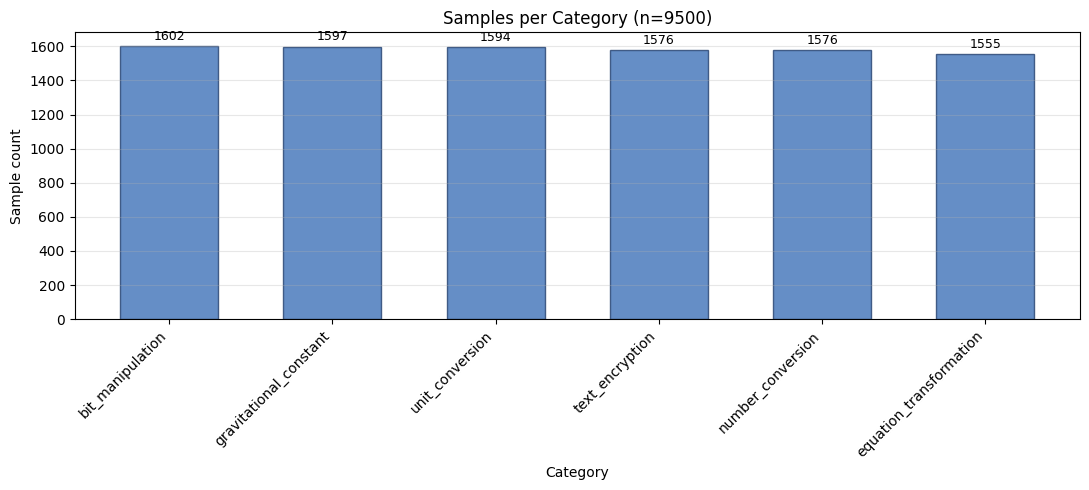

In [7]:
# Samples per category
df['category'].value_counts()
fig, ax = plt.subplots(figsize=(11, 5))
counts = df['category'].value_counts()
bars = ax.bar(range(len(counts)), counts.values, width=0.6, color='#4a7abc', edgecolor='#2c4876', alpha=0.85)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            int(bar.get_height()), ha='center', va='bottom', fontsize=9)
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, rotation=45, ha='right')
ax.set_xlabel('Category')
ax.set_ylabel('Sample count')
ax.set_title(f'Samples per Category (n={len(df)})')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import tiktoken

tok = tiktoken.get_encoding('cl100k_base')
df['token_len'] = (df['prompt'] + '\n' + df['answer'].astype(str)).apply(lambda x: len(tok.encode(x)))
print(f'Token lengths — min: {df["token_len"].min()}, max: {df["token_len"].max()}, mean: {df["token_len"].mean():.0f}')

In [ ]:
# Token length distribution (overall + per category)
fig, axes = plt.subplots(2, 1, figsize=(11, 9))

# Top: overall histogram
ax = axes[0]
xs = df['token_len']
ax.hist(xs, bins=60, color='#4a7abc', edgecolor='#2c4876', alpha=0.85)
ax.axvline(xs.mean(), color='green', linestyle=':', linewidth=1.5, label=f'mean={xs.mean():.0f}')
ax.set_xlabel('Token length (prompt + answer)')
ax.set_ylabel('Sample count')
ax.set_title(f'train.csv — token length distribution\nn={len(xs)}, min={xs.min()}, max={xs.max()}, mean={xs.mean():.0f}')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

# Bottom: breakdown by category
ax = axes[1]
top_cats = df['category'].value_counts().head(8).index
colors = plt.cm.tab10.colors
for i, cat in enumerate(top_cats):
    ys = df[df['category'] == cat]['token_len']
    ax.hist(ys, bins=40, color=colors[i], alpha=0.55, label=f'{cat} (n={len(ys)})')
ax.set_xlabel('Token length')
ax.set_ylabel('Sample count')
ax.set_title('Breakdown by category')
ax.legend(loc='upper right', fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()